# MNIST Digit Recognizer using Neural Networks

## Mini Project

**Objective:**
Build a neural network model that can recognize handwritten digits (0–9) using the MNIST dataset.

**Technologies Used**
- Python
- TensorFlow / Keras
- NumPy
- Matplotlib
- Jupyter Notebook

****

In [1]:
# Import Required Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [3]:
# Load the MNIST Dataset

## Load MNIST Dataset
The MNIST dataset contains handwritten digits from 0–9.
It contains 60,000 training images and 10,000 testing images.

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [5]:
# Visualize Sample Images
# It will visualize some handwritten digits from the dataset.

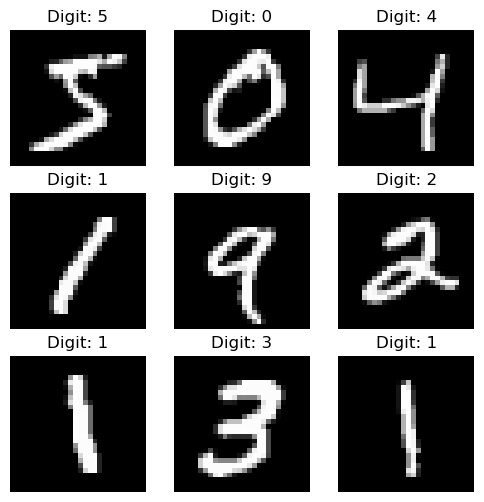

In [27]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.show()

In [7]:
# Data Preprocessing

In [29]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [30]:
# Reshape the data

In [31]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [32]:
# Neural Network Model

In [33]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(10,activation='softmax')

])

In [34]:
# Model summary:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Compile the Model

In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
# Train the Model

In [38]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test,y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.7800 - loss: 0.6657 - val_accuracy: 0.9331 - val_loss: 0.2168
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9474 - loss: 0.1749 - val_accuracy: 0.9630 - val_loss: 0.1217
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9644 - loss: 0.1170 - val_accuracy: 0.9695 - val_loss: 0.0958
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9707 - loss: 0.0940 - val_accuracy: 0.9751 - val_loss: 0.0782
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9760 - loss: 0.0781 - val_accuracy: 0.9761 - val_loss: 0.0724
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9789 - loss: 0.0688 - val_accuracy: 0.9780 - val_loss: 0.0665
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9809 - loss: 0.0618 - val_accuracy: 0.9814 - val_loss: 0.0557
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9828 -

In [39]:
# Evaluate Model Performance

In [40]:
test_loss, test_acc = model.evaluate(x_test,y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9846 - loss: 0.0502
Test Accuracy: 0.9846000075340271


In [41]:
# Make Predictions

In [42]:
prediction = model.predict(x_test[5].reshape(1,28,28,1))

print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", y_test[5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Predicted Digit: 1
Actual Digit: 1


In [43]:
# Visualize Prediction

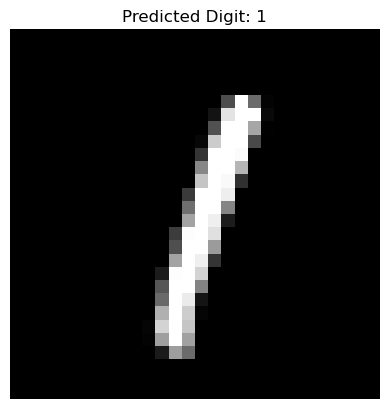

In [44]:
plt.imshow(x_test[5].reshape(28,28), cmap='gray')
plt.title("Predicted Digit: " + str(np.argmax(prediction)))
plt.axis("off")
plt.show()

In [45]:
# Ploting Training Accuracy
# Visualizing model performance.

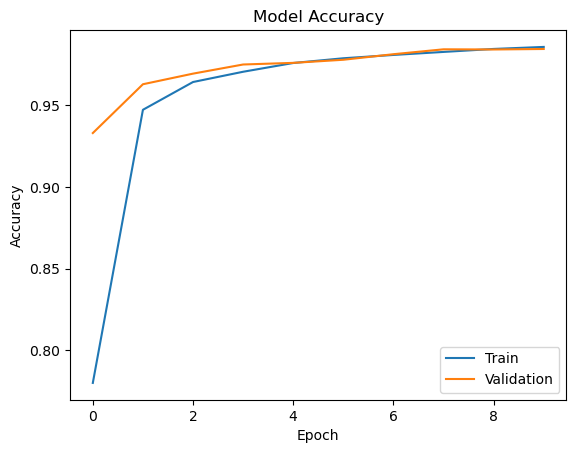

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()